# 02 — What the model is allowed to know (and the proof it can't cheat)

**The stake:** the most common way energy-price backtests lie is *future leakage* — features that quietly encode information unavailable when the bid was actually due. Leakage inflates backtest revenue silently, and the error only surfaces when real money underperforms the study. This notebook shows the feature matrix and then **proves** its causality with a truncation experiment.

## The issue-time convention

Every forecast in this project is issued at **09:00 on D-1**, one hour before ERCOT's 10:00 Day-Ahead Market gate closure. At that moment, the market rules say the following is knowable:

| Information | Known through | Minimum legal lag vs delivery day D |
|---|---|---|
| Real-time (RTM) prices | end of D-2 | **48h** |
| Day-ahead (DAM) prices | delivery day D-1 (cleared ~13:30 on D-2) | **24h** |
| Ancillary clearing prices (MCPC) | cleared with the DAM | **24h** |
| Load / wind / solar **actuals** | published with delay → we require D-2 | **48h** |
| Calendar | deterministic | 0h |

**A deliberate honesty choice:** ERCOT's day-ahead *forecasts* of load, wind, and solar (which a production system would use) expire from the ISO's report archive and cannot be reconstructed for a 2024 study window. Rather than pretend actuals were forecastable, we use **lagged actuals as persistence proxies** — strictly weaker information than a real forecast feed. This is recorded in the model card as a limitation; live deployment would only improve on the numbers reported here.

In [1]:
import pandas as pd

from forecast_to_dispatch.config import load_config, resolve_path
from forecast_to_dispatch.features.build import build_features
from forecast_to_dispatch.viz import eda
from forecast_to_dispatch.viz.style import apply_style

config = load_config()
apply_style()
processed = resolve_path(config, "processed")

X = pd.read_parquet(processed / "features.parquet")
targets = pd.read_parquet(processed / "targets.parquet")
panel = pd.read_parquet(processed / "ercot_prices.parquet")
print(f"{X.shape[0]:,} forecastable hours x {X.shape[1]} features; targets: {list(targets.columns)}")
X.tail(3)

4,128 forecastable hours x 28 features; targets: ['y_price', 'y_spread']


,rtm_lag48,rtm_lag72,rtm_lag168,rtm_roll24_mean,rtm_roll24_max,rtm_roll24_std,rtm_roll168_mean,rtm_roll168_max,dam_lag24,dam_lag48,...,net_load_lag48,net_load_lag168,net_load_roll168_mean,hour_sin,hour_cos,hour,day_of_week,month,is_weekend,is_holiday
interval_start,,,,,,,,,,,,,,,,,,,,,
2024-06-29 21:00:00-05:00,35.1275,31.4150,34.9400,31.540938,58.3275,8.383974,27.551027,131.9975,25.78,31.79,...,55341.992951,54300.763358,44453.623781,-0.707107,0.707107,21,5,6,1,0
2024-06-29 22:00:00-05:00,28.4575,30.0875,23.6375,31.473021,58.3275,8.402841,27.549494,131.9975,24.06,28.44,...,50645.218545,47284.004853,44475.021380,-0.500000,0.866025,22,5,6,1,0
2024-06-29 23:00:00-05:00,23.0000,27.1575,20.1725,31.299792,58.3275,8.537452,27.546830,131.9975,19.11,22.03,...,44088.426884,42004.479108,44486.199026,-0.258819,0.965926,23,5,6,1,0


In [2]:
def _load_exog():
    raw = resolve_path(config, "raw")
    exog = pd.read_parquet(raw / "ercot_wind_solar_2024.parquet").join(
        pd.read_parquet(raw / "ercot_native_load_2024.parquet")
    )
    exog["net_load_mw"] = exog["load_mw"] - exog["wind_mw"] - exog["solar_mw"]
    return exog

exog = _load_exog()
print("exogenous drivers:", list(exog.columns))

exogenous drivers: ['solar_mw', 'wind_mw', 'load_mw', 'net_load_mw']


## The feature catalog (28 features, every one with a declared legal lag)

The catalog is *data*, not convention: `FEATURE_SPEC` maps every feature to its source series and lag, and the test suite iterates it — a feature added below the legal minimum lag fails CI before it can contaminate a backtest.

| Feature | Source | Lag | Transform |
|---|---|---|---|
| `rtm_lag48` | `rtm_price` | 48h | lag |
| `rtm_lag72` | `rtm_price` | 72h | lag |
| `rtm_lag168` | `rtm_price` | 168h | lag |
| `rtm_roll24_mean` | `rtm_price` | 48h | 24h mean |
| `rtm_roll24_max` | `rtm_price` | 48h | 24h max |
| `rtm_roll24_std` | `rtm_price` | 48h | 24h std |
| `rtm_roll168_mean` | `rtm_price` | 48h | 168h mean |
| `rtm_roll168_max` | `rtm_price` | 48h | 168h max |
| `dam_lag24` | `dam_price` | 24h | lag |
| `dam_lag48` | `dam_price` | 48h | lag |
| `dam_lag168` | `dam_price` | 168h | lag |
| `spread_lag48` | `dart_spread` | 48h | lag |
| `spread_roll168_mean` | `dart_spread` | 48h | 168h mean |
| `as_total_lag24` | `as_total` | 24h | lag |
| `load_lag48` | `load_mw` | 48h | lag |
| `load_lag168` | `load_mw` | 168h | lag |
| `wind_lag48` | `wind_mw` | 48h | lag |
| `solar_lag48` | `solar_mw` | 48h | lag |
| `net_load_lag48` | `net_load_mw` | 48h | lag |
| `net_load_lag168` | `net_load_mw` | 168h | lag |
| `net_load_roll168_mean` | `net_load_mw` | 48h | 168h mean |
| `hour_sin` | `calendar` | 0h | lag |
| `hour_cos` | `calendar` | 0h | lag |
| `hour` | `calendar` | 0h | lag |
| `day_of_week` | `calendar` | 0h | lag |
| `month` | `calendar` | 0h | lag |
| `is_weekend` | `calendar` | 0h | lag |
| `is_holiday` | `calendar` | 0h | lag |

Three feature families carry the market logic: **price history** (autoregressive structure and the weekly cycle), **DAM information** (the market's own day-ahead expectation, legitimately known for D-1), and **net-load drivers** (the physics: scarcity = high demand + weak renewables).

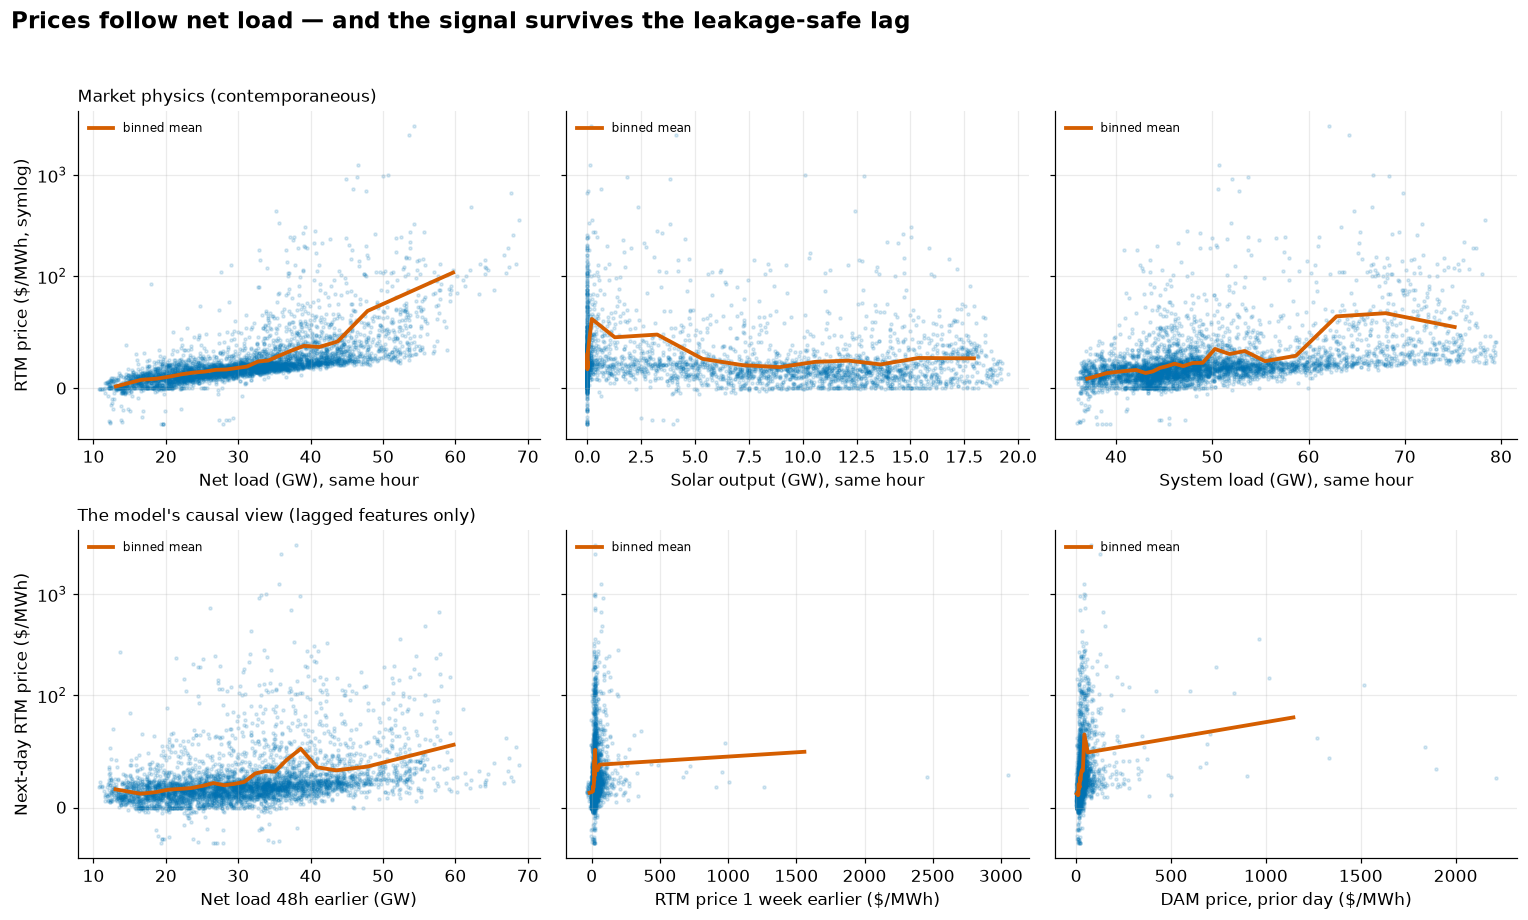

In [3]:
fig = eda.fig19_feature_target_relationships(panel, exog=_load_exog(), X=X, y=targets['y_price'])

### Interpretation — fig19

**Top row (market physics, same hour):** real-time price rises sharply with net load — Spearman ρ = **0.82** — with the steep nonlinearity all scarcity pricing shows: flat for most of the range, then explosive in the top decile. Solar's effect is the mirror image (its evening fade is what creates the net-load peak).

**Bottom row (the model's causal view):** the same relationships seen only through leakage-safe lags. Net load 48h earlier still correlates at ρ = **0.45** with the next-day price, and the prior-day DAM price — the market's own published expectation — carries ρ = **0.54**. The signal weakens but survives.

**Business consequence:** the gap between the two rows *is* the forecasting problem — and it is why reported revenue capture will land meaningfully below the perfect-foresight ceiling. Any backtest whose capture approaches 100% should be presumed leaky.

## The no-leakage proof (truncation experiment)

Claiming causality is easy; proving it is a five-line experiment. We take one delivery day, **blind every input the market rules say was unknown at its 09:00 D-1 issue time** (all RTM prices from the issue moment onward; DAM and ancillary prices for the delivery day itself), rebuild the features from the blinded data, and compare.

If any feature saw the future, the two matrices differ and the assertion fails. This exact experiment runs in CI (`tests/test_features.py::test_truncation_at_issue_time_changes_nothing`) — the build gate will not pass with a leaky feature.

In [4]:
import numpy as np
from forecast_to_dispatch.features.build import issue_time_for

X_full, _ = build_features(panel)
delivery_day = X_full.index[-24].normalize()
issue = issue_time_for(delivery_day)
print(f"delivery day: {delivery_day:%Y-%m-%d}, forecast issued {issue}")

blinded = panel.copy()
blinded.loc[blinded.index >= issue, ["rtm_price", "dart_spread"]] = np.nan
blinded.loc[blinded.index >= delivery_day,
            ["dam_price", "regup", "regdn", "rrs", "nspin", "ecrs"]] = np.nan

X_blind, _ = build_features(blinded, require_targets=False)
day_idx = X_full.index[X_full.index.normalize() == delivery_day]
pd.testing.assert_frame_equal(X_full.loc[day_idx], X_blind.loc[day_idx])
print(f"PROOF: all {len(day_idx)} delivery-day rows identical with the future blinded — no leakage.")

delivery day: 2024-06-29, forecast issued 2024-06-28 09:00:00-05:00
PROOF: all 24 delivery-day rows identical with the future blinded — no leakage.


## Takeaways

1. Every one of the model's inputs is timestamped and provably available at bid time; the rule is enforced by CI, not by discipline.
2. The physical driver (net load) survives the honesty constraint with usable signal — the model has something real to learn.
3. Using lagged actuals instead of unavailable forecast archives makes our results a **conservative floor**: a production deployment with live ERCOT forecast feeds gets strictly better information.

Next: `03_forecasting_lgbm_vs_lstm.ipynb` — quantile forecasts, calibration honesty, scarcity recall, and what SHAP says the model actually learned.